<a href="https://colab.research.google.com/github/Adhameissa/Deep-learning-course-tasks/blob/main/cnn_project_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import urllib.request
import zipfile
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [7]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
urllib.request.urlretrieve(url, "har.zip")

with zipfile.ZipFile("har.zip", 'r') as zip_ref:
    zip_ref.extractall("har_data")


In [8]:
def load_X(path):
    files = os.listdir(path)
    X = []
    for f in sorted(files):
        data = np.loadtxt(os.path.join(path, f))
        X.append(data)
    return np.transpose(np.array(X), (1, 2, 0))

def load_y(path):
    y = np.loadtxt(path)
    return y

X_train = load_X("har_data/UCI HAR Dataset/train/Inertial Signals/")
y_train = load_y("har_data/UCI HAR Dataset/train/y_train.txt")

X_test = load_X("har_data/UCI HAR Dataset/test/Inertial Signals/")
y_test = load_y("har_data/UCI HAR Dataset/test/y_test.txt")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
# Encode labels (1–6 → 0–5)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)


In [9]:
model = Sequential()

# CNN layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# LSTM layer
model.add(LSTM(100))

# Dense layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,646 (291.59 KB)

 Trainable params: 74,646 (291.59 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.6363 - loss: 0.8623 - val_accuracy: 0.7163 - val_loss: 0.6663
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.7998 - loss: 0.4912 - val_accuracy: 0.7988 - val_loss: 0.5871
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.8712 - loss: 0.3647 - val_accuracy: 0.8157 - val_loss: 0.5693
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9094 - loss: 0.2671 - val_accuracy: 0.8090 - val_loss: 0.5931
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9199 - loss: 0.2569 - val_accuracy: 0.8412 - val_loss: 0.6049
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9370 - loss: 0.1910 - val_accuracy: 0.8867 - val_loss: 0.4064
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9382 - loss: 0.1838 - val_accuracy: 0.8921 - val_loss: 0.4608
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9448 - loss: 0.1448 - val_

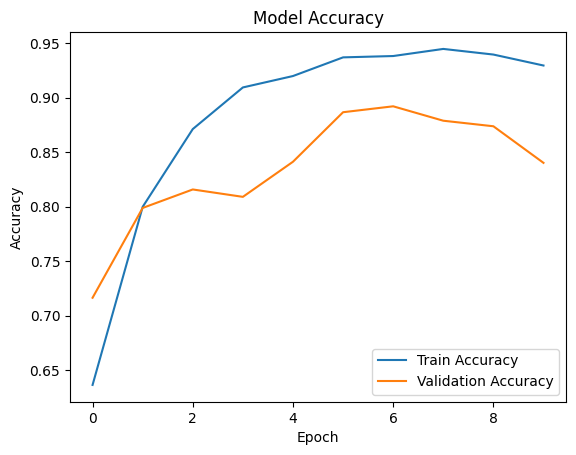

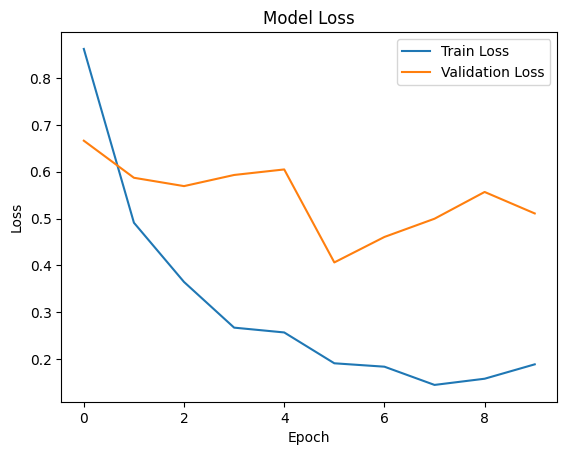

In [11]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


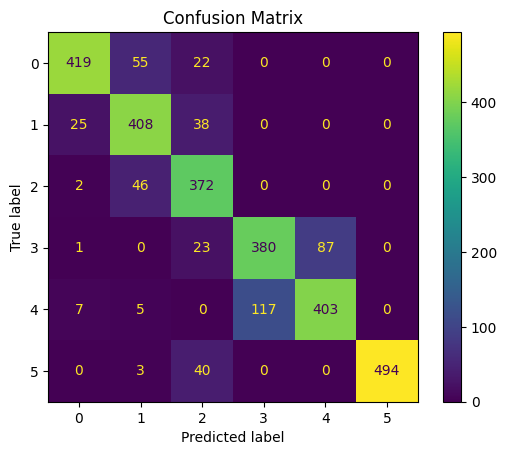

In [12]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [14]:
activity_labels = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

print("\n Sample Predictions:\n")

for i in random.sample(range(len(X_test)), 5):
    sample = X_test[i].reshape(1, X_test.shape[1], X_test.shape[2])
    pred = np.argmax(model.predict(sample), axis=1)[0]

    print("Actual:   ", activity_labels[y_test[i]])
    print("Predicted:", activity_labels[pred])
    print("-" * 40)



 Sample Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Actual:    Walking Downstairs
Predicted: Walking Upstairs
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Actual:    Walking Upstairs
Predicted: Walking Upstairs
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Actual:    Walking
Predicted: Walking Downstairs
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Actual:    Laying
Predicted: Laying
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Actual:    Sitting
Predicted: Sitting
----------------------------------------
